# PCA 1 — Student Participation by Age Group

### Principal Component Analysis of Student Participation by Age Group

This analysis applies Principal Component Analysis (PCA) to examine patterns in student participation across different age groups among the 64 districts of Bangladesh.

Five age groups are considered:

* 5–9 years
* 10–14 years
* 15–19 years
* 20–24 years
* 25–29 years

For each age group, male and female student populations are combined to obtain the total number of students. Since districts differ substantially in population size, the resulting student counts are converted into population-adjusted rates.

PCA is then used to determine whether the variation across these five age-specific student participation indicators can be represented using a smaller number of principal components.

###  This analysis seeks to answer the following research question:

> **How do student participation rates across different age groups vary among the 64 districts of Bangladesh, and can these variations be summarized using a smaller number of principal components?**

 ## Loading the dataset and the necessary libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("housing_census_cleaned.csv")

### Preparing the Student Data and constructing the five indicators

The dataset contains separate male and female student counts for each age group. These variables will be combined to obtain the total student population within each age group.

The analysis uses the following age groups:

- 5–9 years
- 10–14 years
- 15–19 years
- 20–24 years
- 25–29 years

The total population of each district is used to normalize the student counts.


For each age group, the male and female student populations are first combined:

Total Students = Male Students + Female Students

To account for differences in district population size, the student population is expressed as a percentage of the total district population:

Student Participation Rate = (Total Students / Total District Population) × 100

This calculation is performed separately for each of the five age groups: 5–9, 10–14, 15–19, 20–24, and 25–29 years.

Thus, five student participation indicators are obtained, one for each age group.

These five indicators constitute the variables used in the PCA.


In [2]:
student_pca = pd.DataFrame({
    "Division": df["division"],
    "District": df["district"],

    "5-9 years": (
        (df["59_year_male_student_"] + df["59_year_female_student_"])
        / df["population_total"] * 100
    ),

    "10-14 years": (
        (df["1014_years_male_student_"] + df["1014_years_female_student_"])
        / df["population_total"] * 100
    ),

    "15-19 years": (
        (df["1519_years_male_student_"] + df["1519_years_female_student_"])
        / df["population_total"] * 100
    ),

    "20-24 years": (
        (df["2024_years_male_student_"] + df["2024_years_female_student_"])
        / df["population_total"] * 100
    ),

    "25-29 years": (
        (df["2529_years_male_student_"] + df["2529_years_female_student_"])
        / df["population_total"] * 100
    )
})


print( student_pca[["Division", "District", "5-9 years", "10-14 years","15-19 years", "20-24 years", "25-29 years"]].to_string(index=False))

  Division        District  5-9 years  10-14 years  15-19 years  20-24 years  25-29 years
  Barishal         Barguna   7.162868     8.679991     6.158247     2.020423     0.596617
    Khulna        Bagerhat   7.002336     7.827715     5.587833     2.224136     0.633510
  Barishal        Barishal   7.799075     8.957278     6.625543     2.747072     0.783988
  Barishal           Bhola   8.416325     9.536211     5.385668     1.561641     0.499711
  Barishal       Jhalokati   7.732773     9.010829     7.116583     2.434660     0.673211
Chattogram       Bandarban   8.952913     8.924644     5.412736     2.022423     0.694234
  Barishal      Patuakhali   7.469313     8.951318     5.981633     2.235861     0.653465
  Barishal        Pirojpur   7.576062     8.761262     6.168111     2.150067     0.603908
Chattogram    Brahmanbaria   9.765851    10.291411     5.720683     1.526237     0.431082
Chattogram        Chandpur   8.455626     9.342016     6.316461     1.817738     0.502590
  Rajshahi

### Descriptive Statistics

Descriptive statistics are examined before performing PCA to understand the distribution of the five student participation indicators.

The analysis checks the mean, standard deviation, minimum, maximum, and quartiles of each age-specific indicator. 


In [3]:
student_pca.describe()

,5-9 years,10-14 years,15-19 years,20-24 years,25-29 years
count,64.000000,64.000000,64.000000,64.000000,64.000000
mean,7.771586,9.004592,6.069590,2.250085,0.659369
std,2.157362,2.256355,1.405670,0.618837,0.182519
min,2.111758,2.636825,2.035769,0.801624,0.222653
25%,6.938133,8.377437,5.694663,1.943770,0.574445
50%,7.622673,8.937981,5.938751,2.139970,0.630539
75%,8.221096,9.425597,6.318212,2.431426,0.703039
max,20.213703,21.707751,14.113255,4.141690,1.264152


In [4]:
student_pca.isnull().sum()

Division       0
District       0
5-9 years      0
10-14 years    0
15-19 years    0
20-24 years    0
25-29 years    0
dtype: int64

In [5]:
student_pca.shape

(64, 7)

### Correlation Matrix

Before applying PCA, the correlation between the five age-specific student participation indicators is examined.

PCA is particularly useful when several variables contain overlapping information. Therefore, the correlation matrix provides an initial indication of whether student participation across different age groups follows related patterns among the districts.

Since the variables are standardized before PCA, the correlation matrix is calculated as:

Correlation Matrix = (1 / (n − 1)) × Xᵀ × X

where:

* X is the standardized data matrix.
* Xᵀ is the transpose of X.
* n is the number of districts.
* Xᵀ × X represents the matrix multiplication of the transpose of X and X.

The correlation structure will also help us interpret the principal components after the PCA is performed.



In [6]:
correlation_matrix = student_pca[
    ["5-9 years", "10-14 years", "15-19 years", "20-24 years", "25-29 years"]
].corr()

correlation_matrix

,5-9 years,10-14 years,15-19 years,20-24 years,25-29 years
5-9 years,1.000000,0.978006,0.896626,0.431875,0.435062
10-14 years,0.978006,1.000000,0.937943,0.475393,0.477939
15-19 years,0.896626,0.937943,1.000000,0.676367,0.651451
20-24 years,0.431875,0.475393,0.676367,1.000000,0.975004
25-29 years,0.435062,0.477939,0.651451,0.975004,1.000000


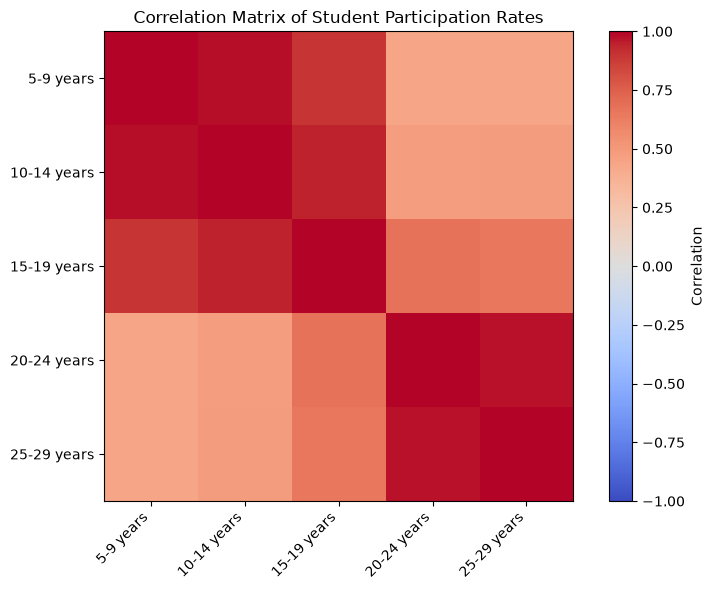

In [7]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of Student Participation Rates")

plt.tight_layout()

plt.savefig("Correlation Matrix of Student participation Rates.png",dpi=300)

plt.show()



### Standardization

The five variables are standardized before performing PCA.

For each observation (i) and variable (j), the standardized value is calculated as:

Standardized Value = (Original Value − Mean of the Variable) / Standard Deviation of the Variable

where:

* Original Value is the observed value for a particular district and variable.
* Mean of the Variable is the average value of that variable across all districts.
* Standard Deviation of the Variable measures the variability of that variable across all districts.

Standardization transforms the variables so that they have a mean approximately equal to zero and a standard deviation equal to one.

This allows PCA to analyze the correlation structure of the five variables without allowing differences in scale or variability to dominate the result.



In [8]:
features = ["5-9 years", "10-14 years", "15-19 years", "20-24 years", "25-29 years"]

scaler = StandardScaler()

Z = pd.DataFrame(
    scaler.fit_transform(student_pca[features]),
    columns=features
)

Z.insert(0, "District", student_pca["District"].values)
Z.insert(0, "Division", student_pca["Division"].values)

Z.head()

,Division,District,5-9 years,10-14 years,15-19 years,20-24 years,25-29 years
0,Barishal,Barguna,-0.284389,-0.144998,0.063570,-0.374053,-0.346527
1,Khulna,Bagerhat,-0.359389,-0.525706,-0.345433,-0.042264,-0.142796
2,Barishal,Barishal,0.012842,-0.021135,0.398634,0.809446,0.688173
3,Barishal,Bhola,0.301218,0.237472,-0.490392,-1.121274,-0.881661
4,Barishal,Jhalokati,-0.018134,0.002786,0.750723,0.300619,0.076438


In [9]:
Z.tail(5)

,Division,District,5-9 years,10-14 years,15-19 years,20-24 years,25-29 years
59,Rangpur,Panchagarh,0.130177,0.162420,0.003122,-0.722728,-0.499645
60,Rangpur,Rangpur,-0.339122,-0.092631,0.462040,0.721497,0.614406
61,Rangpur,Thakurgaon,-0.105536,-0.007484,0.171035,-0.066570,0.131755
62,Sylhet,Sunamganj,0.387053,0.206049,-0.421401,-0.792328,-1.046310
63,Sylhet,Sylhet,0.197668,0.219251,0.507061,0.970583,0.516457


In [10]:
Z[features].mean()

5-9 years      4.163336e-17
10-14 years   -6.938894e-17
15-19 years   -4.475587e-16
20-24 years    1.110223e-16
25-29 years    3.747003e-16
dtype: float64

In [11]:
Z[features].std()

5-9 years      1.007905
10-14 years    1.007905
15-19 years    1.007905
20-24 years    1.007905
25-29 years    1.007905
dtype: float64

###  Principal Component Analysis (PCA)

PCA transforms the five standardized student participation variables into a new set of mutually orthogonal variables called principal components.

Mathematically, PCA is based on the eigenvalue equation:

Correlation Matrix × Eigenvector = Eigenvalue × Eigenvector

In simple notation:

R × v = λ × v

where:

* R is the correlation matrix of the five standardized variables.
* λ (lambda) is an eigenvalue.
* v (v) is the corresponding eigenvector.

The eigenvalues measure the amount of variance explained by the principal components, while the eigenvectors determine the directions of those components.

The first principal component corresponds to the direction of maximum variance in the standardized data. Each subsequent component explains the maximum remaining variance while remaining orthogonal to the preceding components.

### Eigenvalues and Explained variance 



The eigenvalues indicate how much of the total standardized variance is explained by each principal component.

The proportion of variance explained by the k-th principal component is calculated as:

Explained Variance = Eigenvalue of the Component / Sum of All Eigenvalues

Since there are five original variables, the total number of eigenvalues is five.

The cumulative explained variance is then calculated by adding the explained variance of the principal components successively.

This is used to determine how many principal components are needed to represent a substantial proportion of the information contained in the original five-dimensional dataset.

In [12]:
pca = PCA()

principal_components = pca.fit_transform(Z[features])

explained_variance = pca.explained_variance_

explained_ratio = pca.explained_variance_ratio_

explained_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Eigenvalue": explained_variance,
    "Explained Variance (%)": explained_ratio * 100,
    "Cumulative Variance (%)": np.cumsum(explained_ratio) * 100
})

explained_df


,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,3.851017,75.816897,75.816897
1,PC2,1.126727,22.182444,97.999342
2,PC3,0.068015,1.339036,99.338377
3,PC4,0.023275,0.458227,99.796604
4,PC5,0.010331,0.203396,100.000000


## PCA Scores for all districts

In [13]:
pca_results = pd.DataFrame(
    principal_components,
    columns=[f"PC{i+1}" for i in range(principal_components.shape[1])]
)

pca_results.insert(0, "District", Z["District"].values)
pca_results.insert(0, "Division", Z["Division"].values)



print(pca_results[["Division","District","PC1","PC2","PC3","PC4","PC5"]].to_string())


      Division         District        PC1       PC2       PC3       PC4       PC5
0     Barishal          Barguna  -0.459356 -0.232860  0.290586 -0.107863 -0.068064
1       Khulna         Bagerhat  -0.652606  0.316882  0.016878  0.126566 -0.066455
2     Barishal         Barishal   0.808290  0.776984  0.140176  0.086760 -0.063967
3     Barishal            Bhola  -0.819717 -1.267348 -0.358443 -0.102352  0.071599
4     Barishal        Jhalokati   0.520277  0.096043  0.581576  0.067412 -0.193519
5   Chattogram        Bandarban  -0.075880 -0.248787 -0.759868 -0.019017 -0.238423
6     Barishal       Patuakhali  -0.128648  0.049804  0.038446 -0.045620  0.059132
7     Barishal         Pirojpur  -0.248846 -0.191599  0.201971  0.066050 -0.041144
8   Chattogram     Brahmanbaria  -0.439462 -1.958944 -0.404820  0.199115  0.077936
9   Chattogram         Chandpur  -0.342714 -1.106959  0.184301  0.124326 -0.096663
10    Rajshahi           Bogura  -0.148499  0.763080  0.034394 -0.062021  0.002892
11  

### Principal Component Loadings

The PCA loadings describe the contribution of each original variable to each principal component.

The loading matrix is derived from the eigenvectors of the correlation matrix. A larger absolute loading indicates a stronger contribution of the corresponding age-specific student participation indicator to the principal component.

The signs of the loadings indicate the direction of the relationship, while their magnitudes indicate the strength of the contribution.

These loadings will be used to interpret the underlying patterns represented by the principal components.

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5
5-9 years,0.449409,-0.434700,-0.530402,0.453056,-0.349974
10-14 years,0.464251,-0.396347,-0.072612,-0.401275,0.679033
15-19 years,0.495666,-0.162228,0.750449,-0.076727,-0.398668
20-24 years,0.411667,0.559430,0.122692,0.583267,0.402883
25-29 years,0.409082,0.560950,-0.367661,-0.536314,-0.308514


### Scree Plot

The scree plot displays the eigenvalue associated with each principal component.

The plot helps identify the point at which additional principal components contribute relatively little additional variance. This provides a visual aid for deciding how many components should be retained.

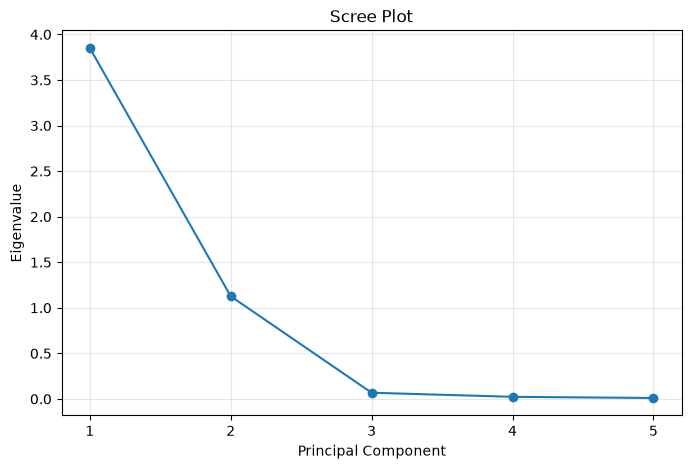

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.xticks(
    range(1, len(explained_variance) + 1)
)

plt.grid(True, alpha=0.3)

plt.savefig("Screeplot.png",dpi=300)
plt.show()

 ### District Principal Component Scores

Each district receives a score for every principal component.

A principal component score represents the position of a district along the corresponding principal component direction.

Districts with high positive or negative scores on a component can therefore be compared according to the underlying student participation pattern represented by that component.

The interpretation of these scores will be based on the explained variance and the corresponding PCA loadings.

In [16]:
pca_results = pd.DataFrame(
    principal_components,
    columns=[f"PC{i+1}" for i in range(principal_components.shape[1])]
)

pca_results.insert(0, "District", Z["District"].values)
pca_results.insert(0, "Division", Z["Division"].values)



print(pca_results[["Division","District","PC1","PC2","PC3","PC4","PC5"]].to_string())

      Division         District        PC1       PC2       PC3       PC4       PC5
0     Barishal          Barguna  -0.459356 -0.232860  0.290586 -0.107863 -0.068064
1       Khulna         Bagerhat  -0.652606  0.316882  0.016878  0.126566 -0.066455
2     Barishal         Barishal   0.808290  0.776984  0.140176  0.086760 -0.063967
3     Barishal            Bhola  -0.819717 -1.267348 -0.358443 -0.102352  0.071599
4     Barishal        Jhalokati   0.520277  0.096043  0.581576  0.067412 -0.193519
5   Chattogram        Bandarban  -0.075880 -0.248787 -0.759868 -0.019017 -0.238423
6     Barishal       Patuakhali  -0.128648  0.049804  0.038446 -0.045620  0.059132
7     Barishal         Pirojpur  -0.248846 -0.191599  0.201971  0.066050 -0.041144
8   Chattogram     Brahmanbaria  -0.439462 -1.958944 -0.404820  0.199115  0.077936
9   Chattogram         Chandpur  -0.342714 -1.106959  0.184301  0.124326 -0.096663
10    Rajshahi           Bogura  -0.148499  0.763080  0.034394 -0.062021  0.002892
11  

In [17]:
pca_results.sort_values(
    "PC1",
    ascending=True
).head(10)

,Division,District,PC1,PC2,PC3,PC4,PC5
47,Rajshahi,Joypurhat,-5.900256,0.073500,0.035688,0.082737,-0.059405
13,Chattogram,Cox's Bazar,-4.557673,-0.531806,-0.254084,0.111513,-0.094729
30,Dhaka,Narayanganj,-1.396905,0.118524,-0.196317,0.106247,0.073078
22,Dhaka,Gazipur,-1.354286,1.105881,-0.285828,0.133625,0.042963
43,Khulna,Meherpur,-1.188197,-0.064160,0.394683,-0.076228,0.058190
17,Khulna,Chuadanga,-1.148103,0.123389,0.016484,-0.248008,0.178060
45,Khulna,Satkhira,-1.001370,0.517024,-0.041783,0.011098,-0.154665
28,Dhaka,Munshiganj,-0.949949,-1.282731,0.155911,0.232025,0.132930
3,Barishal,Bhola,-0.819717,-1.267348,-0.358443,-0.102352,0.071599
16,Chattogram,Lakshmipur,-0.751353,-1.596681,-0.171626,0.115909,-0.037279


In [18]:
pca_results.sort_values(
    "PC1",
    ascending=True
).head(10)

,Division,District,PC1,PC2,PC3,PC4,PC5
47,Rajshahi,Joypurhat,-5.900256,0.073500,0.035688,0.082737,-0.059405
13,Chattogram,Cox's Bazar,-4.557673,-0.531806,-0.254084,0.111513,-0.094729
30,Dhaka,Narayanganj,-1.396905,0.118524,-0.196317,0.106247,0.073078
22,Dhaka,Gazipur,-1.354286,1.105881,-0.285828,0.133625,0.042963
43,Khulna,Meherpur,-1.188197,-0.064160,0.394683,-0.076228,0.058190
17,Khulna,Chuadanga,-1.148103,0.123389,0.016484,-0.248008,0.178060
45,Khulna,Satkhira,-1.001370,0.517024,-0.041783,0.011098,-0.154665
28,Dhaka,Munshiganj,-0.949949,-1.282731,0.155911,0.232025,0.132930
3,Barishal,Bhola,-0.819717,-1.267348,-0.358443,-0.102352,0.071599
16,Chattogram,Lakshmipur,-0.751353,-1.596681,-0.171626,0.115909,-0.037279


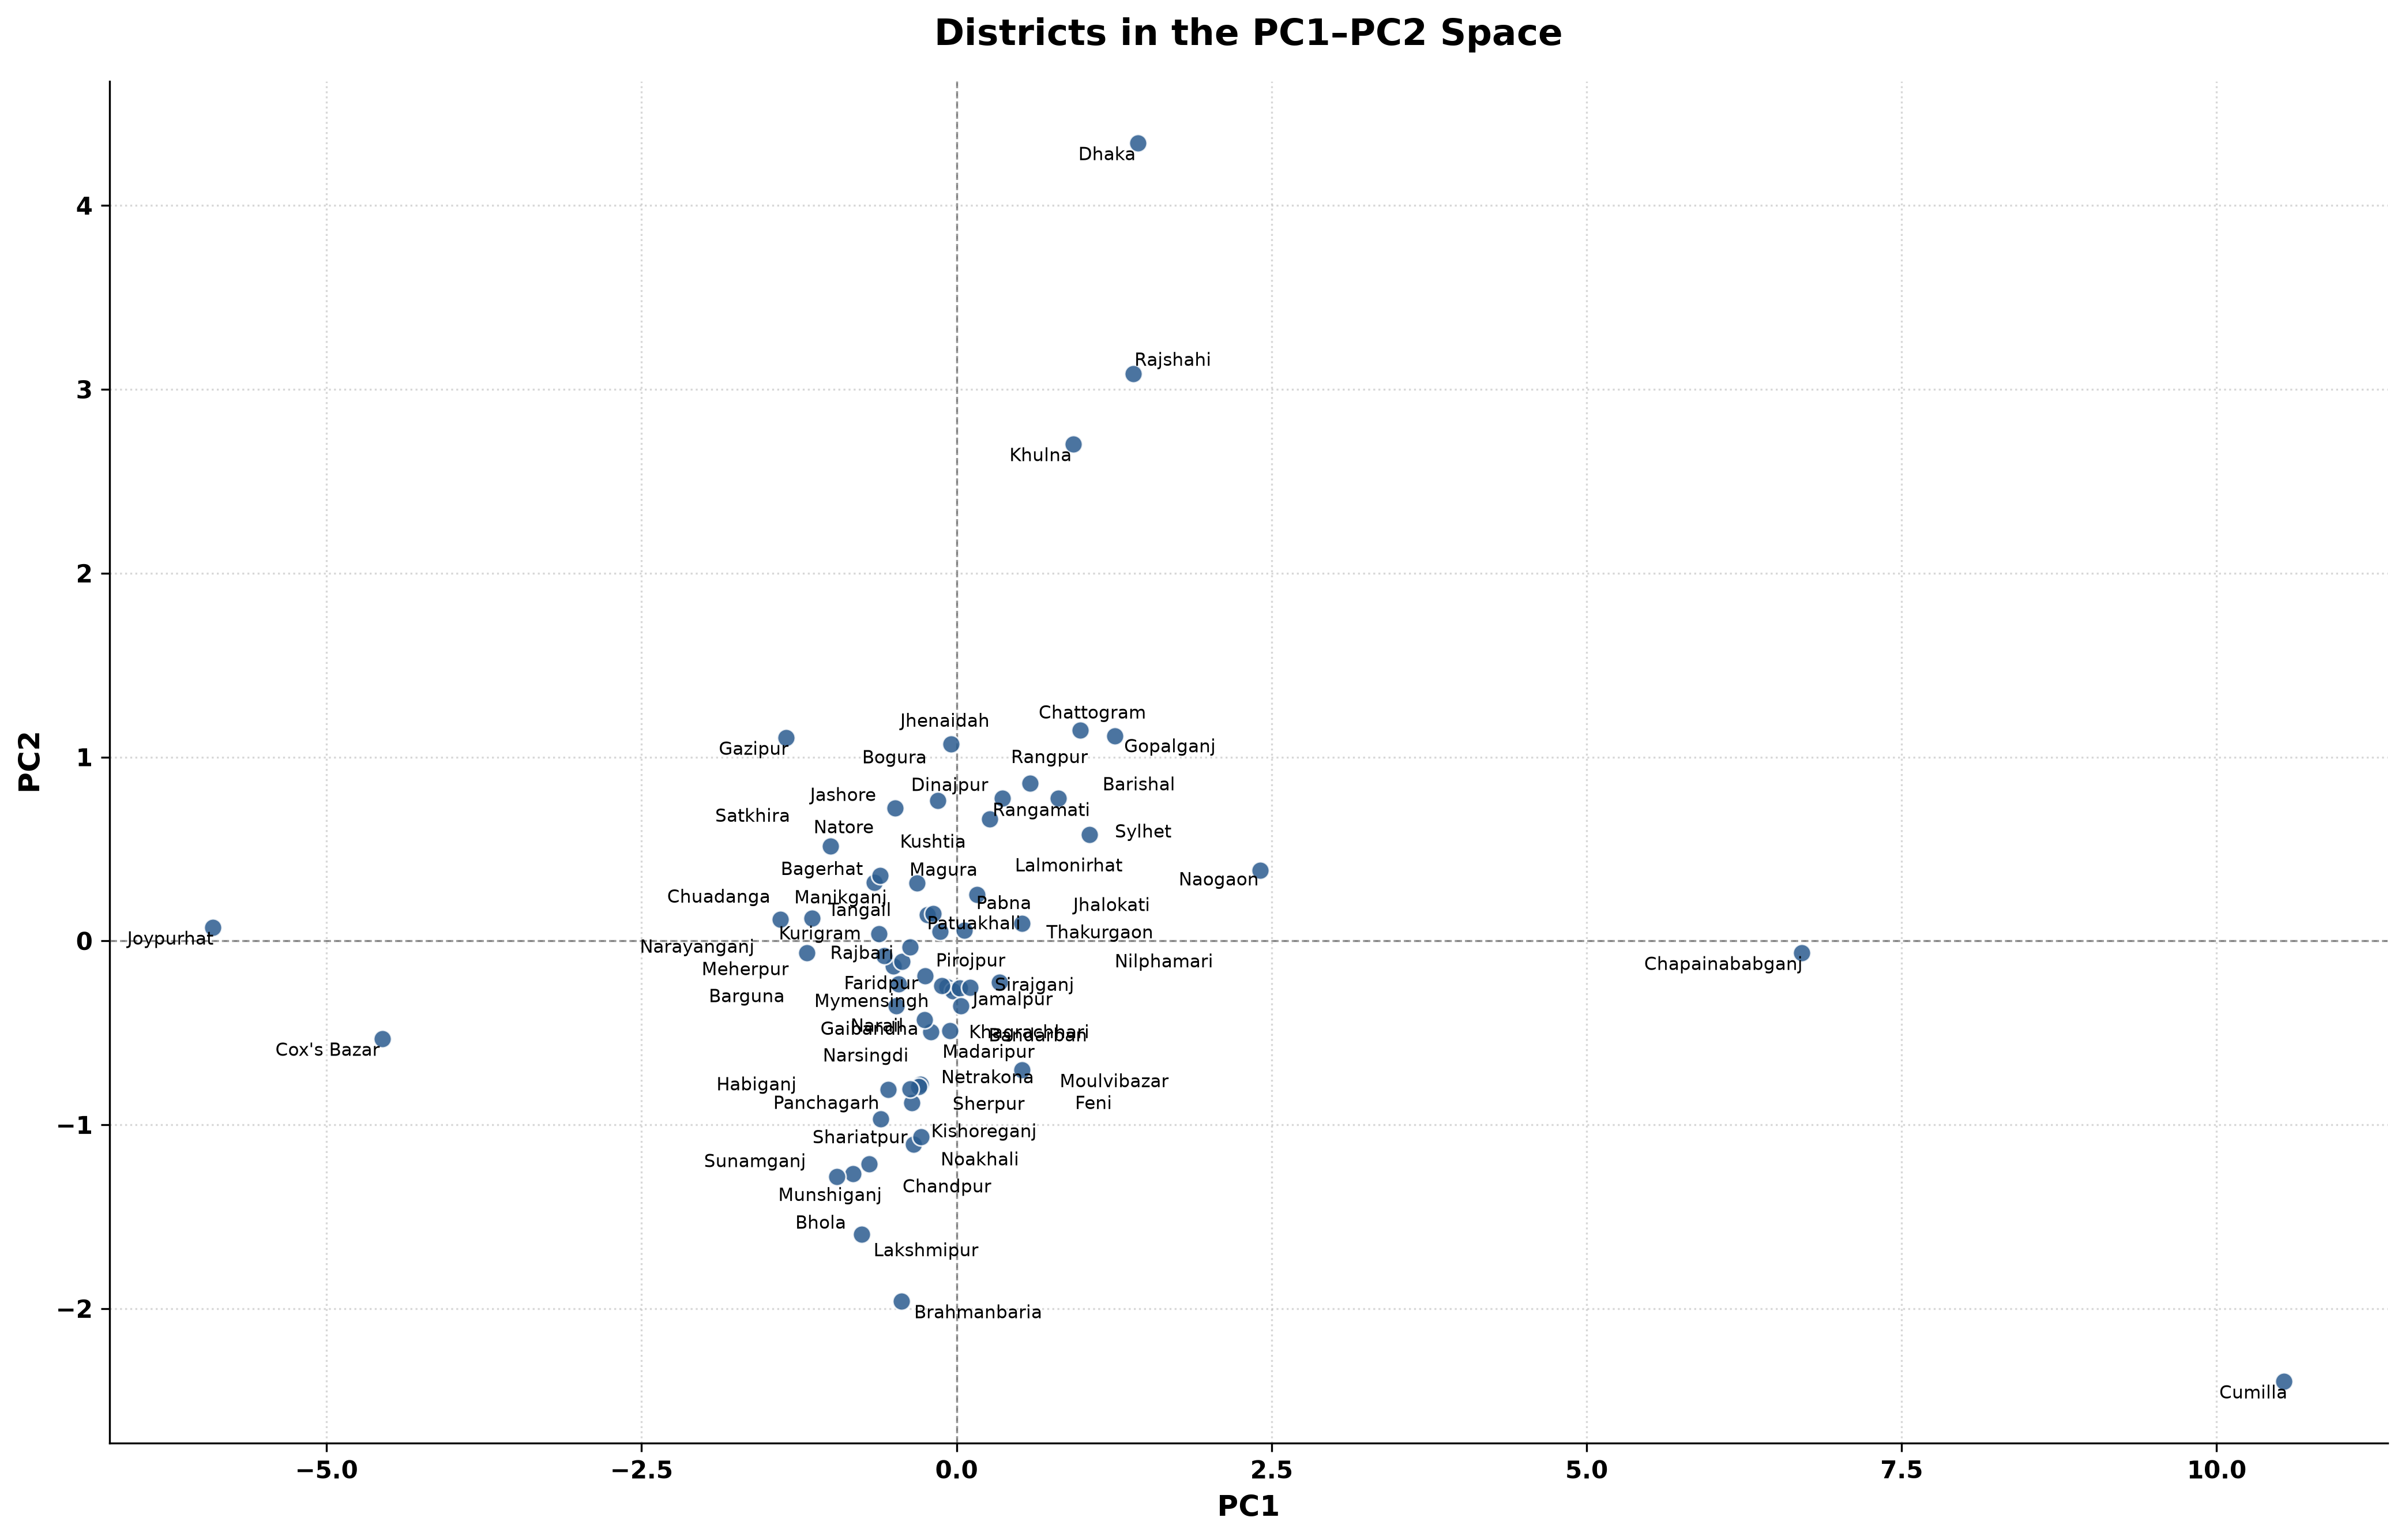

In [19]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(14, 9), dpi=300)

ax.scatter(
    pca_results["PC1"],
    pca_results["PC2"],
    color="#2b5c8f",
    edgecolor="white",
    linewidth=0.7,
    s=55,
    alpha=0.85,
    zorder=3
)

texts = []

for i, district in enumerate(pca_results["District"]):
    texts.append(
        ax.text(
            pca_results["PC1"].iloc[i],
            pca_results["PC2"].iloc[i],
            district,
            fontsize=7.5,
            ha="center",
            va="center"
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand_text=(1.3, 1.5),
    expand_points=(1.3, 1.5),
    force_text=(0.5, 0.8),
    force_points=(0.3, 0.5),
    ensure_inside_axes=True,
    only_move={"points": "xy", "text": "xy"}
)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, zorder=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, zorder=1)

ax.grid(True, linestyle=":", alpha=0.5, zorder=0)

ax.set_xlabel("PC1", fontsize=12, fontweight="bold")
ax.set_ylabel("PC2", fontsize=12, fontweight="bold")

ax.set_title(
    "Districts in the PC1–PC2 Space",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.tick_params(axis="both", labelsize=10)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("PC1.png",dpi=300)
plt.show()


### PCA Interpretation and Findings



### Correlation Analysis

The correlation matrix shows strong positive relationships among the age groups.

The strongest correlations are observed between:

* **5–9 and 10–14 years:** (r = 0.978)
* **20–24 and 25–29 years:** (r = 0.975)
* **10–14 and 15–19 years:** (r = 0.938)
* **5–9 and 15–19 years:** (r = 0.897)

The relatively high correlations indicate that districts with a comparatively large student population in one age group tend to have larger student populations in other age groups as well.

The correlation between the younger age groups and the older age groups is somewhat weaker. For example, the correlation between 5–9 and 20–24 years is (0.432), while the correlation between 5–9 and 25–29 years is (0.435).

This suggests that the five variables contain substantial shared information, making PCA appropriate for dimensionality reduction.

### Explained Variance

The eigenvalue analysis produces the following results:

| Principal Component | Eigenvalue | Explained Variance (%) | Cumulative Variance (%) |
| ------------------- | ---------: | ---------------------: | ----------------------: |
| PC1                 |     3.8510 |                  75.82 |                   75.82 |
| PC2                 |     1.1267 |                  22.18 |                   98.00 |
| PC3                 |     0.0680 |                   1.34 |                   99.34 |
| PC4                 |     0.0233 |                   0.46 |                   99.80 |
| PC5                 |     0.0103 |                   0.20 |                  100.00 |

The first principal component (**PC1**) explains **75.82%** of the total variance, while the second principal component (**PC2**) explains a further **22.18%**.

Together, PC1 and PC2 explain approximately **98.00% of the total variation** in the five original age-group variables.

The remaining three components contribute very little: PC3 explains only 1.34%, PC4 explains 0.46%, and PC5 explains 0.20%.

Therefore, the five-dimensional age-group structure can be represented very effectively using only **two principal components**.

### Interpretation of the Principal Components

The loadings of PC1 are positive and relatively similar across all five age groups:

* 5–9 years: 0.449
* 10–14 years: 0.464
* 15–19 years: 0.496
* 20–24 years: 0.412
* 25–29 years: 0.409

This indicates that **PC1 represents the overall size or intensity of the student population across the five age groups**. Districts with high positive PC1 scores tend to have relatively high student populations across multiple age groups.

PC2 shows a different pattern. The loadings for the younger groups are negative, while those for the older groups are positive:

* 5–9 years: −0.435
* 10–14 years: −0.396
* 15–19 years: −0.162
* 20–24 years: 0.559
* 25–29 years: 0.561

Thus, **PC2 primarily distinguishes districts with relatively greater representation in the older student age groups (20–29 years) from those with relatively greater representation in the younger groups (5–14 years)**.

The inclusion of the 25–29 age group is important here because it has a strong positive loading on PC2 and is highly correlated with the 20–24 age group ((r=0.975)). Excluding this group would therefore remove meaningful information about the older student population structure.

### District-Level Interpretation

The PC scores allow districts to be compared according to the patterns identified by the principal components.

**Cumilla** has the highest PC1 score (10.535), indicating a particularly large overall student population across the five age groups relative to the other districts in this analysis.

**Chapainababganj** also has a high PC1 score (6.708), followed by **Naogaon** (2.409).

In contrast, **Joypurhat** has the lowest PC1 score (−5.900), followed by **Cox's Bazar** (−4.558). These negative scores indicate relatively lower values across the combined age-group structure represented by PC1.

PC2 provides a different perspective. **Dhaka** has a PC2 score of 4.340, followed by **Khulna** (2.703) and **Rajshahi** (3.086). Their positive PC2 scores indicate a relatively stronger contribution from the older age groups, particularly the 20–24 and 25–29 age groups, compared with the younger groups.

### Key Findings

The PCA reveals three important findings:

1. The five student age groups are strongly correlated, indicating substantial overlap in the information they provide.
2. **PC1 explains 75.82% of the total variance** and represents the overall magnitude of the student population across the five age groups.
3. **PC1 and PC2 together explain 98.00% of the total variance**, meaning that the original five-dimensional structure can be represented with only two principal components with very little information loss.

Therefore, PCA provides a mathematically efficient way to summarize the age-wise student population structure of Bangladesh's districts while retaining almost all of the variation contained in the original dataset.
